# Градиентный бустинг

## ЧАСТЬ 1. EDA 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import warnings
warnings.filterwarnings('ignore')

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

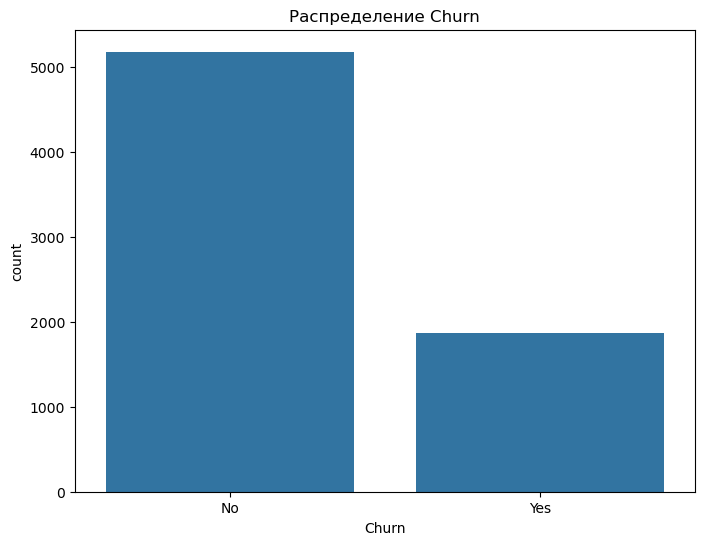

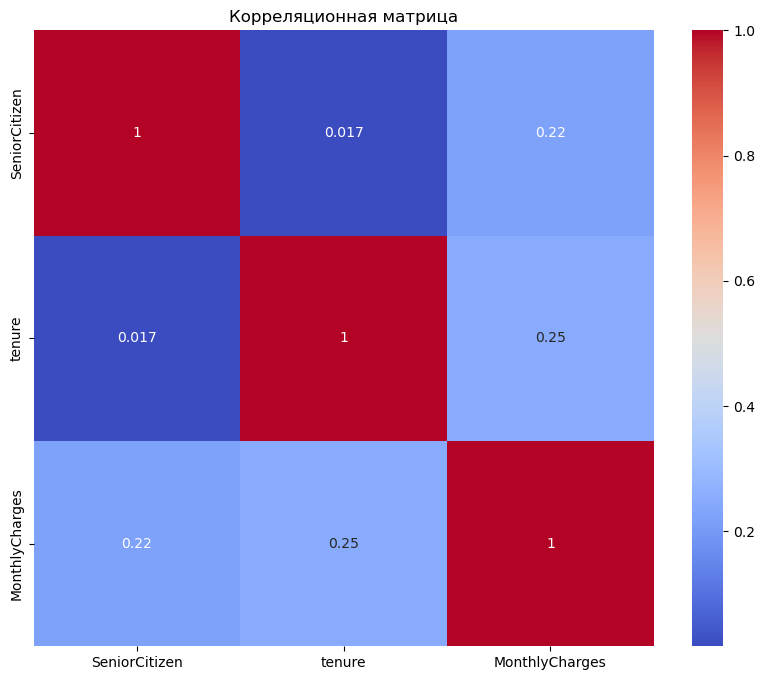

In [2]:
# Загрузка данных
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Первичный осмотр данных
print(df.info())          # Структура: типы данных, пропуски
print(df.describe())      # Описательная статистика для числовых признаков
print(df['Churn'].value_counts())  # Распределение целевой переменной

# Проверка пропусков
print(df.isnull().sum())  # Убеждаемся, что нет missing values

# Визуализация распределения целевой переменной
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Churn')
plt.title('Распределение Churn')
plt.show()

# Корреляционная матрица (для числовых признаков)
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

Типы признаков:

- Числовые (3): SeniorCitizen (0/1), tenure (месяцы), MonthlyCharges ($)
- Категориальные (18): gender, Partner, Contract, PaymentMethod и др.
- Целевая переменная: Churn (No/Yes)

Модель склонна предсказывать No

Ключевые зависимости:
- tenure: среднее 32 месяца, медиана 29 → многие клиенты уходят рано
- MonthlyCharges: среднее $64.76
- TotalCharges

Вывод:
- Наблюдается дисбаланс классов.
- Слабые линейные связи между числовыми признаками


## ЧАСТЬ 2. Preprocessing & Feature Engineering

In [3]:
# Кодирование категориальных переменных
label_encoder = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

# Создаем копию dataframe
df_encoded = df.copy()

for col in categorical_cols:
    if col != 'customerID':  # Исключаем ID — неинформативный признак
        df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

# Удаление лишних признаков
if 'customerID' in df_encoded.columns:
    df_encoded = df_encoded.drop('customerID', axis=1)

# Разделение на признаки и целевую переменную
X = df_encoded.drop('Churn', axis=1)  # Признаки
y = df_encoded['Churn']               # Целевая переменная

# Разделение на train/test (80/20, стратификация по классам, фиксированный random_state)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (5634, 19)
X_test shape: (1409, 19)


Удален customerID - Уникальный идентификатор не нужен для предсказаний.

Все 18 категориальных переменных закодированы через LabelEncoder.

Разбивка на train/test:

- 20% данных в тест
- Фиксированный сид
- Сохранение пропорции классов

### Добавление новых признаков

In [7]:
# Конвертация TotalCharges из str в float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Создание новых признаков
df['tenure_group'] = pd.cut(
    df['tenure'], 
    bins=[0, 12, 24, 48, 72], 
    labels=['<1yr', '1-2yr', '2-4yr', '4+yr']
)
# 🔹 ВАЖНО: Преобразуем категориальный признак в числа (сохраняет порядок)
df['tenure_group'] = df['tenure_group'].cat.codes

df['charges_per_month'] = df['TotalCharges'] / (df['tenure'] + 1)

service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df['total_services'] = df[service_cols].apply(
    lambda row: sum(1 for x in row if x == 'Yes'), axis=1
)

# Кодирование категориальных переменных
label_encoder = LabelEncoder()
# 🔹 Добавляем 'category' в выбор типов данных
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

df_encoded = df.copy()
for col in categorical_cols:
    if col != 'customerID':
        df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

if 'customerID' in df_encoded.columns:
    df_encoded = df_encoded.drop('customerID', axis=1)

# Разделение на признаки и целевую переменную
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print("✅ Все признаки преобразованы в числа")

X_train shape: (5634, 22)
X_test shape: (1409, 22)
✅ Все признаки преобразованы в числа


Новые признаки:

- tenure_group - Группирует клиентов по сроку жизни
- charges_per_month - Средние расходы в месяц
- total_services - Количество подключённых доп. услуг

### Визуализация

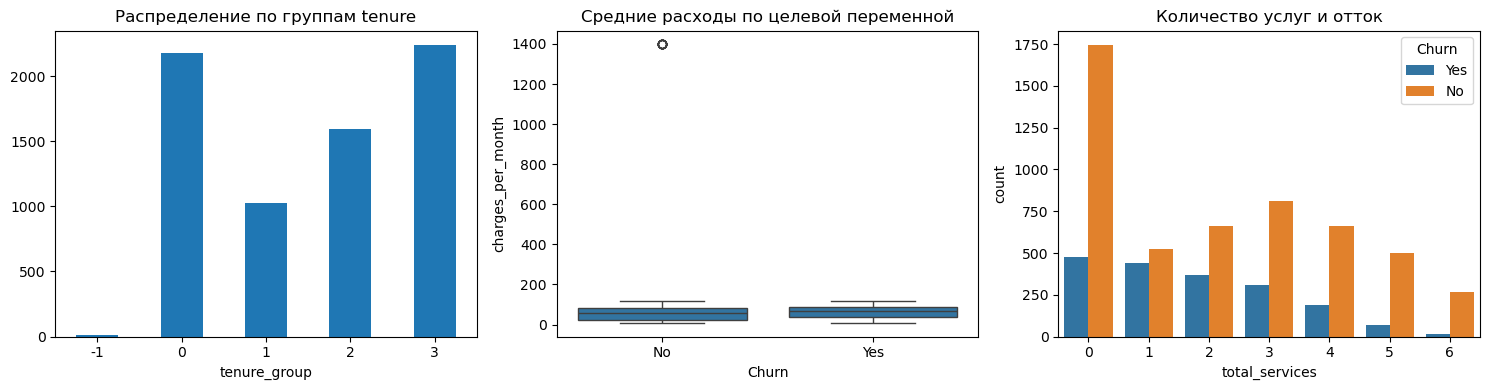

In [8]:
# Визуализация новых признаков
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Распределение tenure_group
df['tenure_group'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Распределение по группам tenure')
axes[0].tick_params(axis='x', rotation=0)

# charges_per_month vs Churn
sns.boxplot(data=df, x='Churn', y='charges_per_month', ax=axes[1])
axes[1].set_title('Средние расходы по целевой переменной')

# total_services vs Churn
sns.countplot(data=df, x='total_services', hue='Churn', ax=axes[2])
axes[2].set_title('Количество услуг и отток')

plt.tight_layout()
plt.show()

Выводы:

- Критический период — первый год: много новых клиентов, но именно в этот период происходит основной отток
- Лояльные клиенты — после 4 лет: клиенты остаются надолго
- Абсолютная величина расходов не является ключевым фактором оттока
- Относительная стоимость (соотношение цена/качество) может быть важнее абсолютной суммы
- Клиенты с большим числом подключённых услуг значительно реже уходят

## ЧАСТЬ 3. Градиентный бустинг

In [10]:
# Инициализация моделей с параметрами "из коробки"
models = {
    'sklearn_GB': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

# Словарь для хранения результатов
results_default = {}
results_tuned = {}

print("=" * 50)
print("Тестирование моделей с параметрами по умолчанию")
print("=" * 50)

for name, model in models.items():
    # Обучение
    model.fit(X_train, y_train)

    # Предсказания
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)

    results_default[name] = {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'f1': f1
    }

    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"  F1-score: {f1:.4f}")

# Настройка гиперпараметров
print("\n" + "=" * 50)
print("Настройка гиперпараметров")
print("=" * 50)

# Параметры для настройки (базовые)
param_grid = {
    'sklearn_GB': {
        'n_estimators': [50, 100],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0]
    },
    'XGBoost': {
        'n_estimators': [50, 100],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0]
    },
    'LightGBM': {
        'n_estimators': [50, 100],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0]
    },
    'CatBoost': {
        'iterations': [50, 100],
        'depth': [3, 5],
        'subsample': [0.8, 1.0]
    }
}

tuned_models = {}

for name, model in models.items():
    print(f"\nНастройка {name}...")

    grid_search = GridSearchCV(
        model,
        param_grid[name],
        cv=3,                    # 3-fold cross-validation
        scoring='roc_auc',       # Оптимизируем по ROC-AUC (важно при дисбалансе)
        n_jobs=-1,               # Используем все ядра
        verbose=0
    )

    grid_search.fit(X_train, y_train)

    # Лучшая модель
    best_model = grid_search.best_estimator_
    tuned_models[name] = best_model

    # Предсказания
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)

    results_tuned[name] = {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'f1': f1,
        'best_params': grid_search.best_params_
    }

    print(f"  Лучшие параметры: {grid_search.best_params_}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"  F1-score: {f1:.4f}")

# Сравнение результатов
print("\n" + "=" * 50)
print("Итоговое сравнение")
print("=" * 50)

results_df_default = pd.DataFrame(results_default).T
results_df_tuned = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != 'best_params'}
                                 for k, v in results_tuned.items()}).T

print("\nРезультаты до настройки:")
print(results_df_default)

print("\nРезультаты после настройки:")
print(results_df_tuned)

# Определение победителя
best_model_default = results_df_default['roc_auc'].idxmax()
best_model_tuned = results_df_tuned['roc_auc'].idxmax()

print(f"Победитель (default params): {best_model_default}")
print(f"Победитель (tuned params): {best_model_tuned}")

Тестирование моделей с параметрами по умолчанию

sklearn_GB:
  Accuracy: 0.8048
  ROC-AUC: 0.8427
  F1-score: 0.5877

XGBoost:
  Accuracy: 0.7786
  ROC-AUC: 0.8204
  F1-score: 0.5439
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000462 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 893
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328

LightGBM:
  Accuracy: 0.7878
  ROC-AUC: 0.8354
  F1-score: 0.5710

CatBoost:
  Accuracy: 0.7984
  ROC-AUC: 0.8376
  F1-score: 0.5710

Настройка гиперпараметров

Настройка sklearn_GB...
  Лучшие параметры: {'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
  

### Итоговое сравнение

Результаты до настройки:

|          |  accuracy |  roc_auc   |     f1|
|-|-|-|-|
|sklearn_GB | 0.804826 | 0.842708 | 0.587706|
|XGBoost     |0.778566 | 0.820367 | 0.543860|
|LightGBM    |0.787793 | 0.835357 | 0.571019|
| CatBoost    |0.798439|  0.837620 | 0.570997|

Результаты после настройки:

|          |  accuracy |  roc_auc    |    f1|
|-|-|-|-|
|sklearn_GB | 0.804826|  0.844277|  0.576271|
|XGBoost     |0.806955|  0.842070|  0.591592|
|LightGBM    |0.802697|  0.845668|  0.574924|
|CatBoost    |0.802697|  0.843684|  0.588757|

Победитель (default params): sklearn_GB

Победитель (tuned params): LightGBM